In [1]:
import torch
import numpy as np
import time

import hockey.hockey_env as h_env

from sac.plots import *
from sac.utils import from_dict, SB3_PARAMS, get_trained_agent
from sac.trainer import HockeyTrainer, SCORE_REWARD, DEFAULT_REWARD
from sac.tournament import PooledTournament

In [2]:
params = SB3_PARAMS
hidden_sizes = [128, 128]
params["alpha"] = 0.1
params["hidden_sizes"] = hidden_sizes
params["lr_critic"] = 1e-3

In [3]:
random_seed = 0

In [4]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [5]:
filepath = f"./results/hl2-{random_seed}"

In [6]:
trainer = HockeyTrainer(params, reward_func=DEFAULT_REWARD)
weak_opponent = h_env.BasicOpponent(weak=True)
strong_opponent = h_env.BasicOpponent(weak=False)

In [7]:
# trainer.load("./agents/strongcont-0", episode=5000)

In [21]:
tournament = PooledTournament(seed=random_seed)
tournament.add_agent(weak_opponent)
tournament.add_agent(strong_opponent)

In [22]:
agent_paths = [
    "./agents/reward-0-5000.pth",
    "./agents/continue-0-10000.pth",
    "./agents/selfplay-0-5000.pth",
    "./agents/strong-0-7000.pth",
]
for agent_path in agent_paths:
    new_agent = get_trained_agent(agent_path)
    tournament.add_agent(new_agent)

In [10]:
trainer.warmup(256)

In [ ]:
max_timesteps = 500
new_episodes = 500
log_interval = 20
train_interval = 10

In [12]:
def evaluate_agent(trainer, opponent):
    rewards, scores = trainer.evaluate(opponent, 100, render=False)
    print("Avg reward:",np.mean(rewards))
    print("Winrate:",0.5 * (np.mean(scores)+1))
    print("Winrate (no ties):", np.mean(np.asarray(scores) == 1))

In [13]:
def add_agent(trainer, tournament, params):
    new_agent = trainer.create_agent(params)
    agent_state = trainer.agent.state()
    new_agent.restore_state(agent_state)
    tournament.add_agent(new_agent)

In [23]:
for i in range(5):
    trainer.train(tournament, new_episodes, train_interval, log_interval, max_timesteps)
    evaluate_agent(trainer, weak_opponent)
    evaluate_agent(trainer, strong_opponent)
    trainer.save_agent(filepath)
    add_agent(trainer, tournament, params)

  2520: Reward:   -5.659 Winrate:    0.350
  2540: Reward:   -7.993 Winrate:    0.250
  2560: Reward:   -7.193 Winrate:    0.350
  2580: Reward:   -9.701 Winrate:    0.175
  2600: Reward:   -6.496 Winrate:    0.350
  2620: Reward:   -7.749 Winrate:    0.325
  2640: Reward:   -5.917 Winrate:    0.375
  2660: Reward:   -6.329 Winrate:    0.375
  2680: Reward:  -10.003 Winrate:    0.175
  2700: Reward:   -7.371 Winrate:    0.350
  2720: Reward:   -5.502 Winrate:    0.400
  2740: Reward:   -7.408 Winrate:    0.325
  2760: Reward:   -3.821 Winrate:    0.500
  2780: Reward:   -9.194 Winrate:    0.200
  2800: Reward:   -7.393 Winrate:    0.300
  2820: Reward:   -6.183 Winrate:    0.350
  2840: Reward:   -5.534 Winrate:    0.425
  2860: Reward:   -6.286 Winrate:    0.325
  2880: Reward:   -5.256 Winrate:    0.400
  2900: Reward:   -6.484 Winrate:    0.400
  2920: Reward:   -2.721 Winrate:    0.525
  2940: Reward:   -2.913 Winrate:    0.525
  2960: Reward:   -3.781 Winrate:    0.450
  2980: Rew

KeyboardInterrupt: 

In [24]:
trainer.evaluate(weak_opponent, render=True)

([8.070184447556748,
  -5.059929591633741,
  -5.035195726642801,
  7.682947295291601,
  -2.5096040418480574],
 [1, 0, 0, 1, 0])

In [25]:
trainer.evaluate(strong_opponent, render=True)

([9.005659156489816,
  8.556432931445126,
  -4.505539397374765,
  6.266850335954432,
  6.711571873831605],
 [1, 1, 0, 1, 1])

In [26]:
trainer.reset()

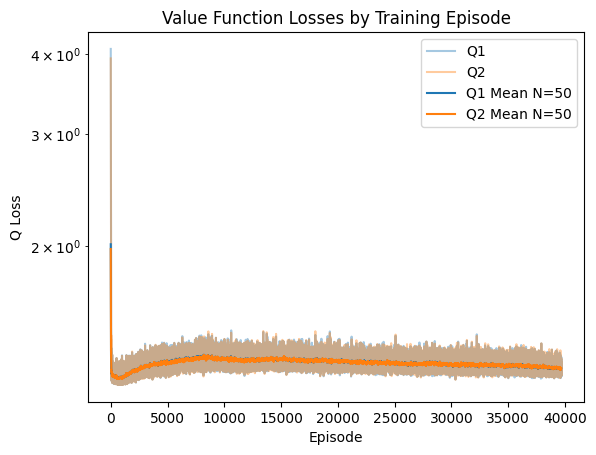

In [27]:
q_losses = np.stack([trainer.logs["Q1_loss"], trainer.logs["Q2_loss"]]).T
plot_q(q_losses, "./results")

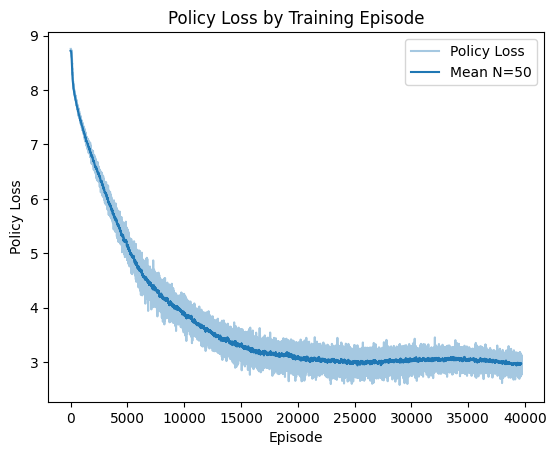

In [28]:
plot_policy_loss(trainer.logs["Policy_loss"], "./results")

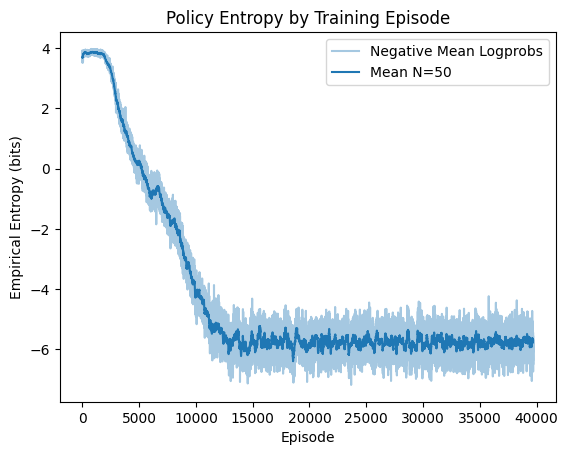

In [29]:
plot_entropy(np.asarray(trainer.logs["Logprobs"]), "./results")

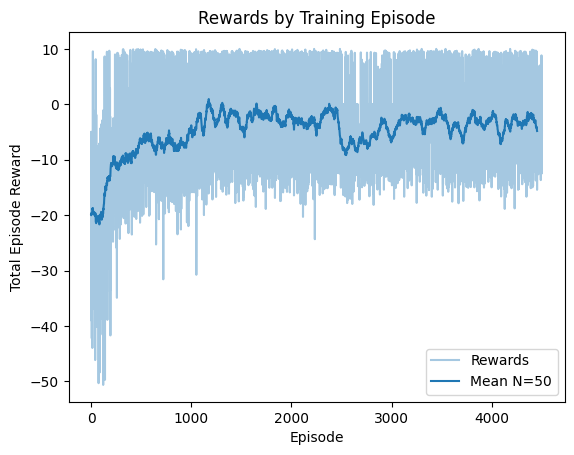

In [30]:
plot_rewards(trainer.logs["Rewards"], "./results")

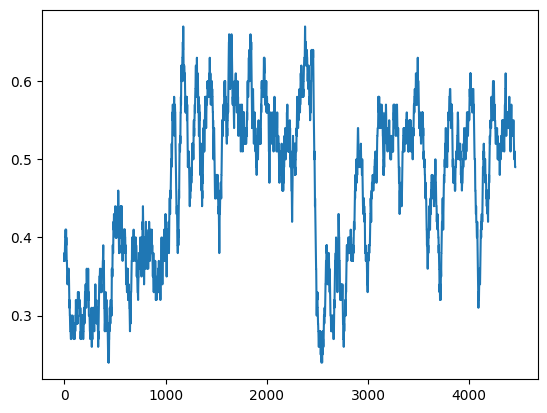

In [31]:
plt.plot(running_mean(0.5*(np.asarray(trainer.logs["Scores"])+1), 50))

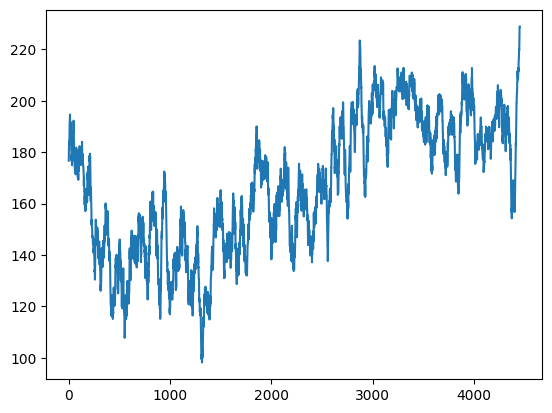

In [32]:
plt.plot(running_mean(trainer.logs["Lengths"], 50))

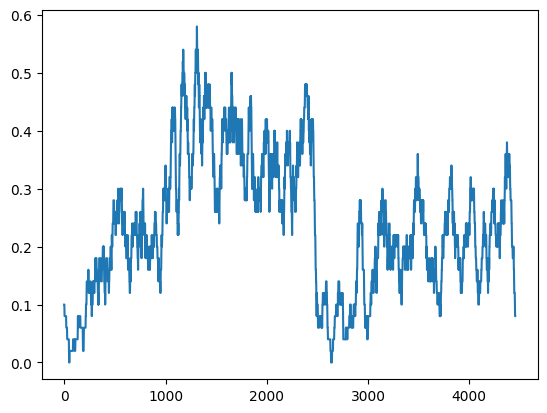

In [33]:
plt.plot(running_mean(np.asarray(trainer.logs["Scores"]) == 1, 50))